# **MLProcess - Smoke Detector**
---
**2 - Data Understanding (EDA)**

In [1]:
# Import the required libraries.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import src.utils as utils

## **1 - Configuration File**
---

In [2]:
# Load the conifguration file.
config = utils.load_config()
utils.print_debug("Config file loaded...")

2026-03-07 01:14:12.343971 Config file loaded...


In [3]:
# Check the configuration file.
config

{'columns_datetime': ['utc'],
 'columns_float': ['temperature',
  'humidity_pct',
  'pressure',
  'pm10',
  'pm25',
  'nc05',
  'nc10',
  'nc25'],
 'columns_int': ['tvoc', 'co2', 'raw_h2', 'raw_ethanol', 'fire_alarm'],
 'features': ['temperature',
  'humidity_pct',
  'pressure',
  'pm10',
  'tvoc',
  'co2',
  'raw_h2',
  'raw_ethanol'],
 'label': 'fire_alarm',
 'path_data_raw': 'data/raw/smoke_detection_iot.csv',
 'path_data_test': ['data/interim/X_test.pkl', 'data/interim/y_test.pkl'],
 'path_data_train': ['data/interim/X_train.pkl', 'data/interim/y_train.pkl'],
 'path_data_valid': ['data/interim/X_valid.pkl', 'data/interim/y_valid.pkl'],
 'path_data_validated': 'data/interim/validated_data.pkl',
 'range_co2': [400, 60000],
 'range_fire_alarm': [0, 1],
 'range_humidity_pct': [10.74, 75.2],
 'range_nc05': [0, 65535],
 'range_nc10': [0, 65535],
 'range_nc25': [0, 65535],
 'range_pm10': [0.0, 14333.69],
 'range_pm25': [0, 65535],
 'range_pressure': [930.852, 939.861],
 'range_raw_ethanol

## **2 - Load Data**
---

**Note:** Do EDA only on the train set.

In [4]:
# Load the train set.
X_train = utils.deserialize_data(config["path_data_train"][0])
y_train = utils.deserialize_data(config["path_data_train"][1])

Data deserialized from data/interim/X_train.pkl
Data deserialized from data/interim/y_train.pkl


In [5]:
# Join X_train and y_train.
dataset = pd.concat(
    [X_train, y_train],
    axis = 1
)

In [6]:
# Check the joined train set.
dataset

,temperature,humidity_pct,pressure,pm10,tvoc,co2,raw_h2,raw_ethanol,fire_alarm
51420,29.520,39.97,937.567,1.86,26,400,12848,20752,0
56406,59.890,11.23,936.761,463.79,60000,3818,11846,17318,0
52217,27.140,42.63,937.511,2.19,117,433,12770,20621,0
55564,49.950,24.31,936.897,0.73,21060,653,12679,18931,0
14753,14.112,53.18,938.854,2.06,1141,456,12858,19446,1
...,...,...,...,...,...,...,...,...,...
61185,20.514,29.66,936.873,0.81,5724,400,13043,19602,0
30715,22.040,49.19,939.656,2.55,32,400,13258,20228,1
41785,24.570,53.34,938.769,1.69,1166,402,12896,19448,1
47379,26.290,50.96,938.731,1.80,1310,400,12970,19404,1


## **3 - Exploratory Data Analysis**
---

Check distribution, outliers, and correlation.

### **3.1. Label Distribution**

In [7]:
# Check the proportion of the label.
dataset["fire_alarm"].value_counts(normalize=True)

fire_alarm
1    0.714634
0    0.285366
Name: proportion, dtype: float64

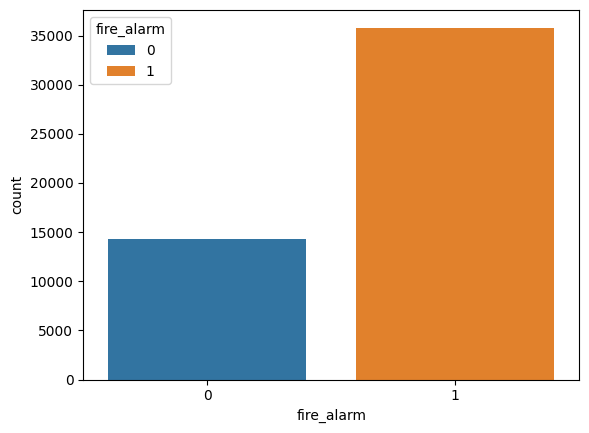

In [8]:
sns.countplot(
    data = dataset,
    x = "fire_alarm",
    hue="fire_alarm"
)
plt.show()

- 71.5% label are class 1, thus we need to do label balancing.

### **3.2. Temperature Distribution**

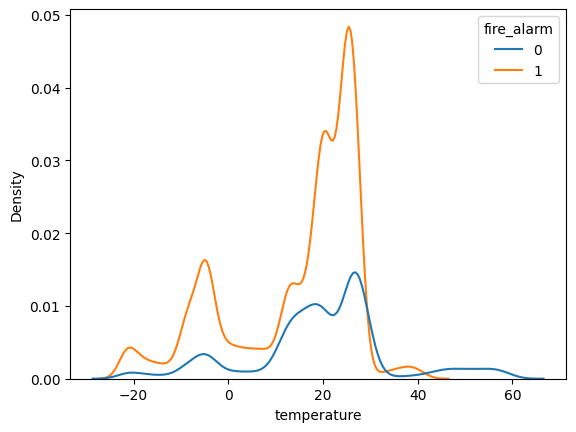

In [9]:
sns.kdeplot(
    data = dataset,
    x = "temperature",
    hue = "fire_alarm"
)
plt.show()

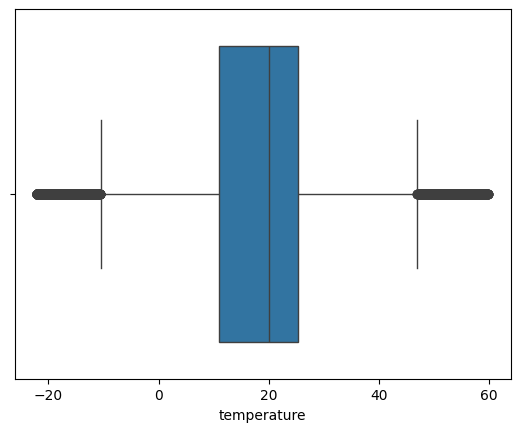

In [10]:
sns.boxplot(
    data = dataset,
    x = "temperature"
)
plt.show()

### **3.3. Humidity Distribution**

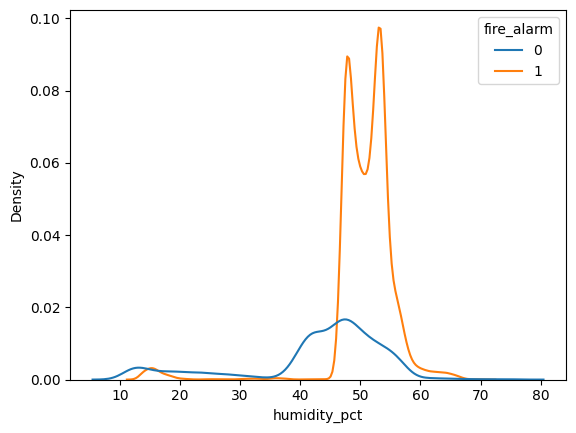

In [11]:
sns.kdeplot(
    data = dataset,
    x = "humidity_pct",
    hue = "fire_alarm"
)
plt.show()

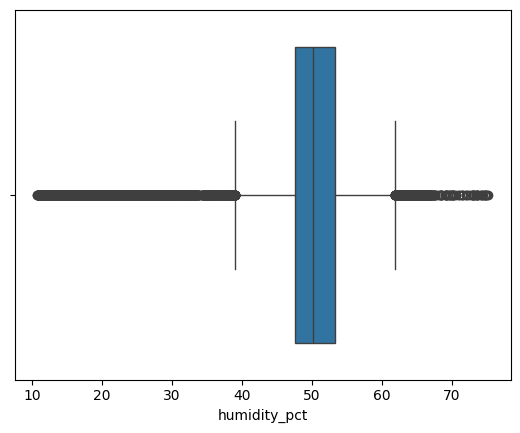

In [12]:
sns.boxplot(
    data = dataset,
    x = "humidity_pct"
)
plt.show()

### **3.4. Pressure Distribution**

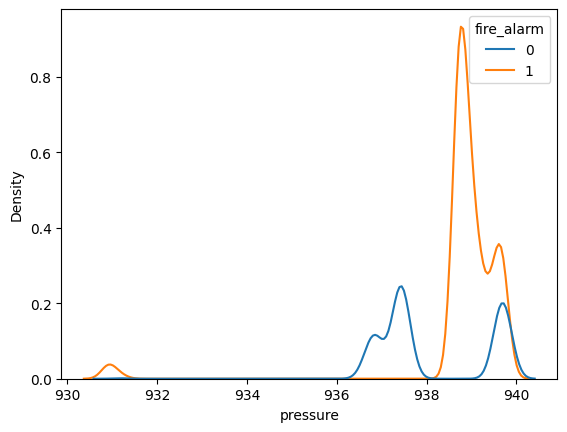

In [13]:
sns.kdeplot(
    data = dataset,
    x = "pressure",
    hue = "fire_alarm"
)
plt.show()

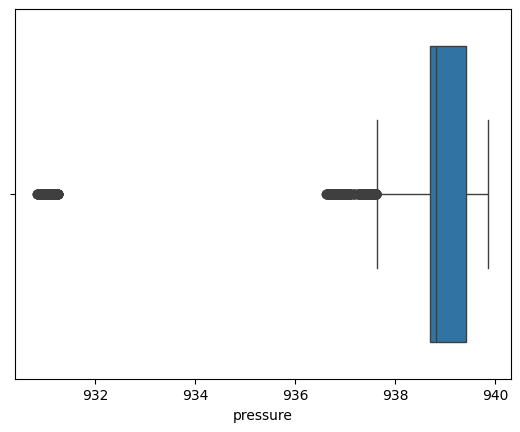

In [14]:
sns.boxplot(
    data = dataset,
    x = "pressure"
)
plt.show()

### **3.5. PM10 Distribution**

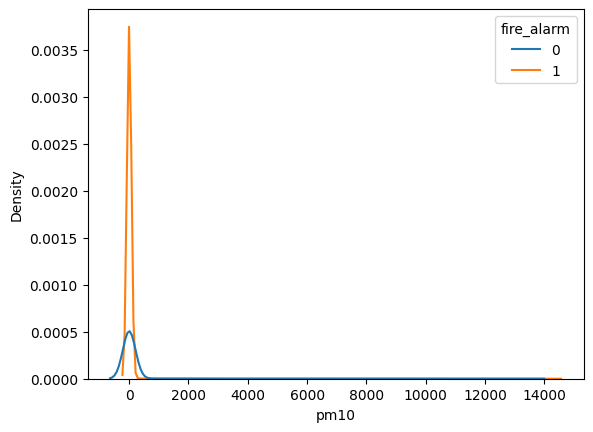

In [15]:
sns.kdeplot(
    data = dataset,
    x = "pm10",
    hue = "fire_alarm"
)
plt.show()

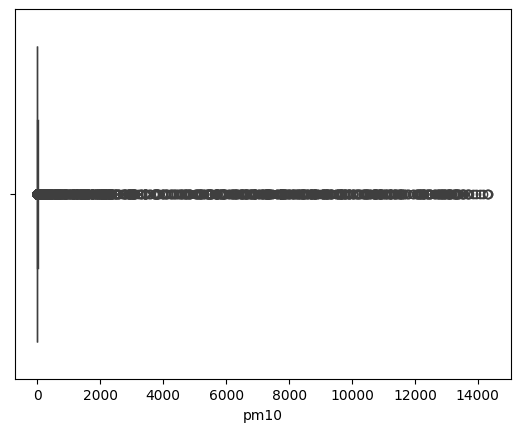

In [16]:
sns.boxplot(
    data = dataset,
    x = "pm10"
)
plt.show()

### **3.6. TVOC Distribution**

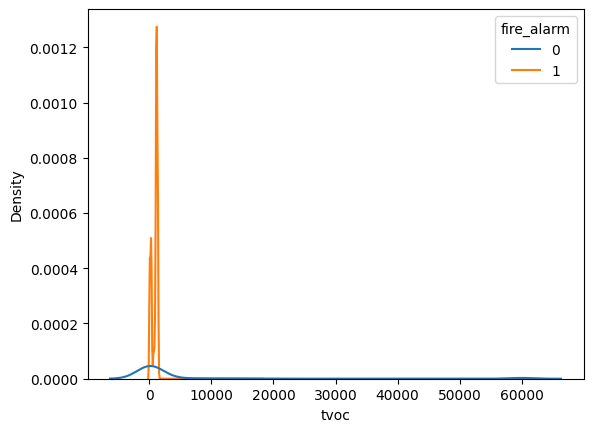

In [17]:
sns.kdeplot(
    data = dataset,
    x = "tvoc",
    hue = "fire_alarm"
)
plt.show()

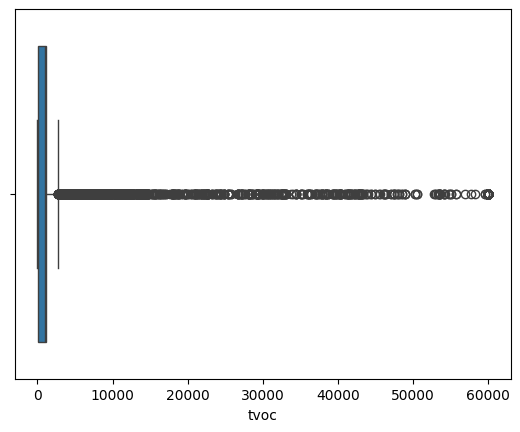

In [18]:
sns.boxplot(
    data = dataset,
    x = "tvoc"
)
plt.show()

### **3.7. CO2 Distribution**

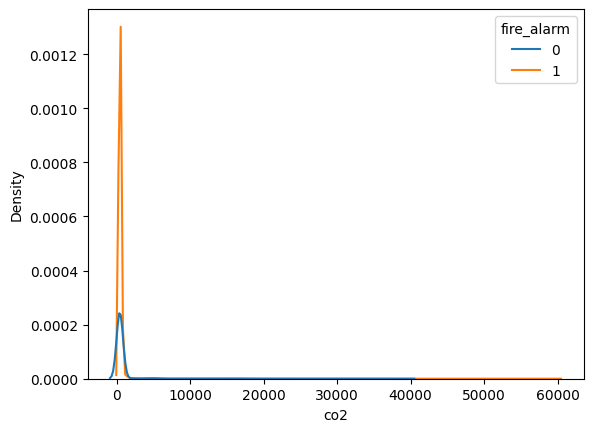

In [19]:
sns.kdeplot(
    data = dataset,
    x = "co2",
    hue = "fire_alarm"
)
plt.show()

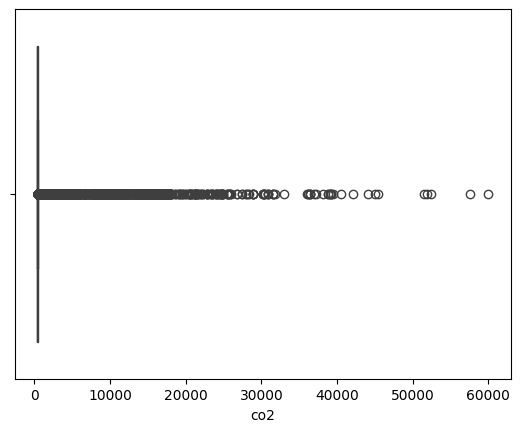

In [20]:
sns.boxplot(
    data = dataset,
    x = "co2"
)
plt.show()

### **3.8. H2 Distribution**

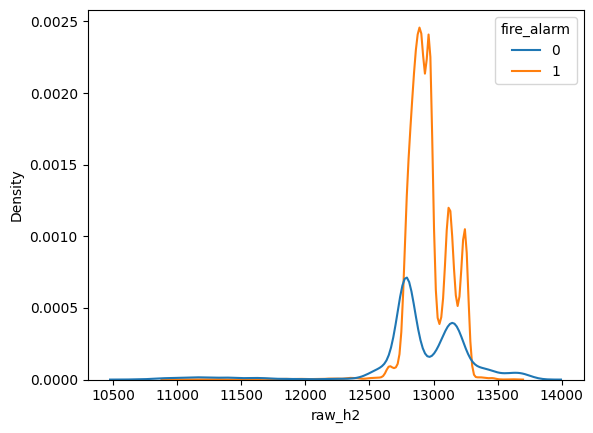

In [21]:
sns.kdeplot(
    data = dataset,
    x = "raw_h2",
    hue = "fire_alarm"
)
plt.show()

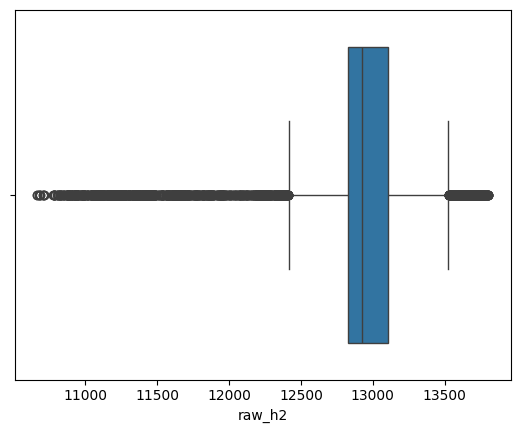

In [22]:
sns.boxplot(
    data = dataset,
    x = "raw_h2"
)
plt.show()

### **3.9. Ethanol Distribution**

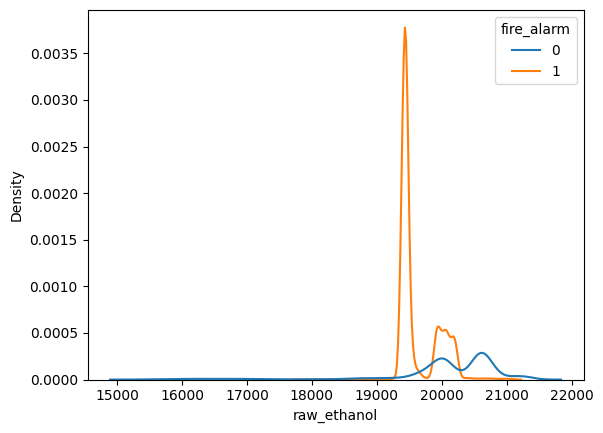

In [23]:
sns.kdeplot(
    data = dataset,
    x = "raw_ethanol",
    hue = "fire_alarm"
)
plt.show()

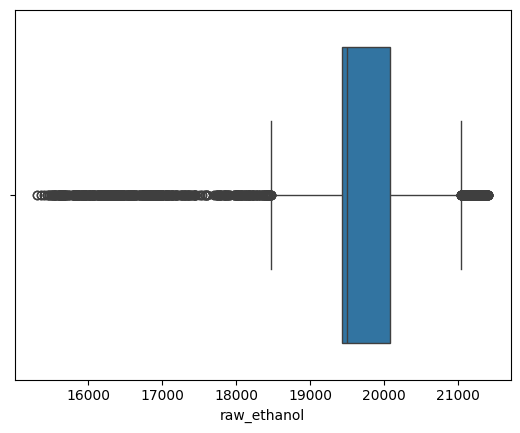

In [24]:
sns.boxplot(
    data = dataset,
    x = "raw_ethanol"
)
plt.show()

### **3.10. Check Correlation**

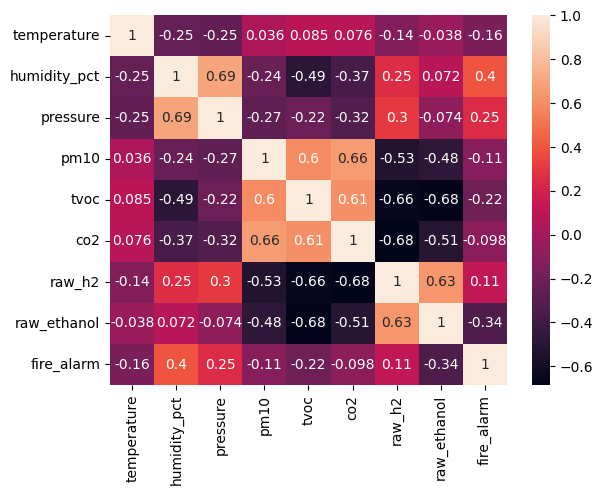

In [25]:
sns.heatmap(
    dataset.corr(numeric_only=True),
    annot=True
)
plt.show()

**Summary:**
1. Label balancing: SMOTE
2. Outliers removal: IQR-based